<a href="https://colab.research.google.com/github/RubenArielArguello-ai/app-turnos-peluqueria/blob/main/Copia_de_turno_barto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ruben_Ariel_Arguello
##Proyecto_turnos
###ML+DL


In [10]:
# Instala la librería de Supabase si no la tenés instalada. Es fundamental para conectar con la base de datos.
!pip install supabase
import pandas as pd # Importa pandas para manejar los datos en DataFrames, ¡es un clásico!
from supabase import create_client, Client # Importa las herramientas de Supabase para conectarte a tu base de datos.

# Configura tus credenciales de Supabase. ¡Ojo con estas que son la llave a tu base de datos!
SUPABASE_URL = "https://jofwgwxicszvpfhrphoh.supabase.co"
SUPABASE_KEY = "sb_publishable_FPy1xS8bRcqSd6Y6Fs9LiA_YpoqKtMl"

# Inicializa el cliente de Supabase. Esto te conecta directamente con tu proyecto.
supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

# 1. Traemos los datos de la tabla de turnos. Asegurate de que 'turnos' sea el nombre exacto de tu tabla.
respuesta_turnos = supabase.table('turnos').select('*').execute()
df_turnos = pd.DataFrame(respuesta_turnos.data) # Convierte los datos de la respuesta a un DataFrame de pandas.

# 2. Si tuvieras una tabla de clientes, la cargarías acá, pero ahora está comentada.
#respuesta_clientes = supabase.table('clientes').select('*').execute()
#df_clientes = pd.DataFrame(respuesta_clientes.data)

print("¡Datos descargados con éxito!") # Mensaje para saber que todo salió bien.
print("Columnas en turnos:", df_turnos.head()) # Muestra las primeras filas para ver cómo vienen los datos.
#print("Columnas en clientes:", df_clientes.columns.tolist()) # Si cargaras clientes, esto mostraría sus columnas.

¡Datos descargados con éxito!
Columnas en turnos:    id                        created_at        nombre        telefono  \
0   1  2026-07-01T05:32:13.458189+00:00  Carlos Peres  =5491138706608   

        fecha     hora  
0  2026-07-24  11:35pm  


In [11]:
PROJECT_NAME = "turnos_barto" # Define el nombre de tu proyecto, como para tenerlo identificado.
print("conectado el proyecto:", PROJECT_NAME) # Confirma que el nombre del proyecto se estableció.

conectado el proyecto: turnos_barto


In [12]:
# Librerías esenciales que vas a usar en el notebook.
import pandas as pd # Para manejar y analizar los datos, ¡un fierro!
import numpy as np # Para operaciones numéricas, arrays y cálculos matemáticos.

# Machine Learning clásico para modelos predictivos sencillos.
from sklearn.model_selection import train_test_split # Para dividir los datos en conjuntos de entrenamiento y prueba.
from sklearn.linear_model import LogisticRegression # Un modelo para clasificación, ideal para sí/no, como si asiste o no.

# Deep Learning con TensorFlow/Keras para redes neuronales más complejas.
import tensorflow as tf # La librería de Google para construir y entrenar modelos de Deep Learning.
from tensorflow import keras # Keras, la API de alto nivel de TensorFlow, que facilita la creación de redes neuronales.

#PROCESAR LOS DATOS REALES Y SIMULAR LA DURACION

In [13]:
import numpy as np # Necesario para operaciones numéricas y arrays.
from sklearn.model_selection import train_test_split # Para dividir los datos en entrenamiento y prueba.
from sklearn.ensemble import RandomForestRegressor # El modelo que vamos a usar para predecir duraciones.
from sklearn.metrics import mean_absolute_error # Para evaluar qué tan bien predice nuestro modelo.
import joblib # Para guardar y cargar modelos fácilmente.
from google.colab import files # Para poder descargar archivos desde Colab.

# 1. Función para convertir formatos de hora como '11:35pm' a un número decimal (Ej: 23.58).
def hora_a_decimal(hora_str):
    try:
        hora_str = str(hora_str).strip().lower() # Limpia la cadena de hora (quita espacios y la pasa a minúsculas).
        es_pm = 'pm' in hora_str # Verifica si es PM.
        hora_clean = hora_str.replace('am', '').replace('pm', '').strip() # Quita 'am' o 'pm' y limpia de nuevo.
        partes = hora_clean.split(':') # Divide la hora en horas y minutos.

        horas = int(partes[0]) # Convierte la parte de la hora a entero.
        minutos = int(partes[1]) if len(partes) > 1 else 0 # Convierte los minutos a entero, si existen.

        if es_pm and horas < 12: # Si es PM y la hora es menor a 12 (ej. 1pm, 2pm), le suma 12.
            horas += 12
        if not es_pm and horas == 12: # Si es AM y son las 12 (medianoche), lo convierte a 0.
            horas = 0

        return horas + (minutos / 60.0) # Devuelve la hora como un número decimal.
    except: # Si hay algún error en la conversión, por si la hora viene mal.
        return 12.0 # Devolvemos un valor por defecto (mediodía) para no romper todo.

# 2. Aplicamos la conversión a tu columna 'hora' original.
# Si 'df_turnos' tiene pocos registros, generamos una base simulada más grande para entrenar mejor el modelo.
if len(df_turnos) > 0:
    df_turnos['hora_numerica'] = df_turnos['hora'].apply(hora_a_decimal) # Aplica la función a la columna 'hora'.
    # Simulamos un ID de servicio ficticio (0: Corte, 1: Barba, 2: Tintura) para las pruebas.
    df_turnos['servicio_id'] = np.random.choice([0, 1, 2], size=len(df_turnos)) # Asigna servicios aleatorios.
    base_data = df_turnos # Usa tus datos como base.
else:
    base_data = pd.DataFrame() # Si no hay datos, crea un DataFrame vacío.

# Para asegurarnos de tener suficientes ejemplos para entrenar el modelo hoy:
n_muestras = 500 # Cantidad de muestras simuladas.
np.random.seed(42) # Fija la "semilla" para que los resultados aleatorios sean siempre los mismos.
horas_simuladas = np.random.uniform(9, 21, n_muestras) # Simula horas entre las 9 y las 21.
servicios_simulados = np.random.choice([0, 1, 2], size=n_muestras) # Simula IDs de servicio.
# La duración real simulada que el modelo intentará aprender (en minutos).
duraciones_simuladas = 20 + (servicios_simulados * 20) + (horas_simuladas * 0.4) + np.random.normal(0, 4, n_muestras)

# Crea un DataFrame con los datos simulados para el entrenamiento.
df_entrenamiento = pd.DataFrame({
    'servicio_id': servicios_simulados,
    'hora_numerica': horas_simuladas,
    'duracion_minutos': duraciones_simuladas
})

print("Dataset listo para entrenar. Primeras filas:") # Mensaje de confirmación.
print(df_entrenamiento.head()) # Muestra las primeras filas del DataFrame de entrenamiento.

Dataset listo para entrenar. Primeras filas:
   servicio_id  hora_numerica  duracion_minutos
0            1      13.494481         43.045445
1            2      20.408572         67.629825
2            0      17.783927         31.397557
3            0      16.183902         24.142358
4            0      10.872224         27.757875


#ENTRENAR EL MODELO REGRESOR

In [14]:
# Separamos las características (lo que usamos para predecir) y la etiqueta (lo que queremos predecir).
X = df_entrenamiento[['servicio_id', 'hora_numerica']] # Características: ID del servicio y hora numérica.
y = df_entrenamiento['duracion_minutos'] # Etiqueta: Duración en minutos.

# Dividimos el set de datos en entrenamiento (80%) y prueba (20%).
# Esto es clave para evaluar si el modelo generaliza bien a datos que nunca vio.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamos el regresor (en este caso, un Random Forest).
# 'n_estimators' son la cantidad de árboles en el bosque, 'random_state' asegura reproducibilidad.
modelo_duracion = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_duracion.fit(X_train, y_train) # Entrena el modelo con los datos de entrenamiento.

# Evaluamos el modelo con los datos de prueba.
preds = modelo_duracion.predict(X_test) # Hacemos predicciones sobre el conjunto de prueba.
error_promedio = mean_absolute_error(y_test, preds) # Calculamos el Error Absoluto Medio.
print(f"\n¡Modelo entrenado exitosamente!") # Mensaje de éxito.
print(f"Error medio absoluto: {error_promedio:.2f} minutos.") # Muestra el error promedio.

# Exportamos y descargamos el archivo .pkl (es el modelo guardado) a tu computadora.
joblib.dump(modelo_duracion, 'predictor_duracion.pkl') # Guarda el modelo entrenado en un archivo.
print("\nDescargando 'predictor_duracion.pkl'...") # Mensaje para el usuario.
files.download('predictor_duracion.pkl') # Activa la descarga del archivo.


¡Modelo entrenado exitosamente!
Error medio absoluto: 4.05 minutos.

Descargando 'predictor_duracion.pkl'...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Modelo a  (ML) prediccion de ausentismo ("No-Show") LogisticRegression
##Modelo b (DL) pronostico demanda semanal de turnos . Red neuronal simple TensorFlow y keras

In [15]:
import numpy as np # Para manejar arrays y cálculos numéricos.
import pandas as pd # Para trabajar con DataFrames.
from sklearn.model_selection import train_test_split # Para dividir los datos.
from sklearn.linear_model import LogisticRegression # Modelo de Regresión Logística.
import tensorflow as tf # La librería principal de Deep Learning.
from tensorflow import keras # API de Keras para construir modelos de redes neuronales.

# 1. SIMULACIÓN DE HISTORIAL (Para entrenar los dos modelos nuevos)
# Como la tabla de 'turnos' es muy chiquita, creamos datos realistas simulados basados en tu estructura de Supabase.
np.random.seed(42) # Fija la semilla para que los resultados simulados sean siempre los mismos.
n_registros = 300 # Cantidad de registros que vamos a simular.

nombres_random = ["Carlos", "Matias", "Lucas", "Enzo", "Diego", "Javier", "Tomas"] # Nombres aleatorios.
data_simulada = { # Diccionario con los datos que vamos a generar.
    'nombre': np.random.choice(nombres_random, n_registros), # Asigna nombres al azar.
    'dia_semana': np.random.randint(1, 7, n_registros), # Días de la semana (1=Lunes, 6=Sábado).
    'hora_decimal': np.random.uniform(9.0, 20.0, n_registros), # Horarios entre las 9 y las 20hs.
    'asistio': np.random.choice([1, 0], n_registros, p=[0.82, 0.18]) # Simula asistencia (82% asiste, 18% falta).
}
df_ml = pd.DataFrame(data_simulada) # Crea un DataFrame con los datos simulados.

# ==========================================
# 🚀 PREDICTOR 1: ¿EL CLIENTE VA A FALTAR? (ML - Regresión Logística)
# ==========================================
# Características para el modelo de ausentismo: día de la semana y hora.
X_ausentismo = df_ml[['dia_semana', 'hora_decimal']]
y_ausentismo = df_ml['asistio'] # Etiqueta: si asistió (1) o no (0).

# Dividimos los datos para el modelo de ausentismo en entrenamiento y prueba.
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_ausentismo, y_ausentismo, test_size=0.2, random_state=42)

modelo_ausentismo = LogisticRegression() # Inicializa el modelo de Regresión Logística.
modelo_ausentismo.fit(X_train_a, y_train_a) # Entrena el modelo con los datos de entrenamiento.


# Prueba rápida del predictor de asistencia. ¡A ver qué onda!
ejemplo_cliente = [[6, 14.5]] # Un ejemplo: Sábado (día 6) a las 14:30hs (14.5).
probabilidad_asistencia = modelo_ausentismo.predict_proba(ejemplo_cliente)[0][1] # Predice la probabilidad de asistencia.
print(f"🔮 Probabilidad de que el cliente asista el Sábado a las 14:30hs: {probabilidad_asistencia:.2%}") # Muestra el resultado.


# ==========================================
# 🧠 PREDICTOR 2: PRONÓSTICO DE DEMANDA (Deep Learning - TensorFlow)
# ==========================================
# Agrupamos los datos simulados para ver cuántos turnos se agendan por día.
df_demanda = df_ml.groupby('dia_semana').size().reset_index(name='total_turnos') # Calcula el total de turnos por día.

X_demanda = df_demanda['dia_semana'].values # Característica: día de la semana.
y_demanda = df_demanda['total_turnos'].values # Etiqueta: cantidad total de turnos.

# Creamos una Red Neuronal Simple con Keras.
modelo_dl = keras.Sequential([ # Una red neuronal secuencial (capa tras capa).
    keras.layers.Dense(units=8, activation='relu', input_shape=[1]), # Primera capa, 8 neuronas, activación ReLU.
    keras.layers.Dense(units=4, activation='relu'), # Segunda capa, 4 neuronas, activación ReLU.
    keras.layers.Dense(units=1) # Capa de salida: una neurona para predecir la cantidad de turnos.
])

modelo_dl.compile(optimizer='adam', loss='mean_squared_error') # Compila el modelo: optimizador Adam y error cuadrático medio como función de pérdida.

# Entrenamos la red neuronal. ¡Aprende, maquina!
print("\n🧠 Entrenando la Red Neuronal de Demanda...") # Mensaje de inicio de entrenamiento.
historial = modelo_dl.fit(X_demanda, y_demanda, epochs=150, verbose=0) # Entrena por 150 épocas, sin mostrar el progreso en cada una.

# Predecir turnos para un día específico (ej: Día 6 = Sábado).
prediccion_turnos = modelo_dl.predict(np.array([[6]]))[0][0] # Hace una predicción para el día 6.
print(f"📈 Cantidad estimada de turnos para el próximo Sábado: {int(round(prediccion_turnos))} turnos") # Muestra la predicción redondeada.

🔮 Probabilidad de que el cliente asista el Sábado a las 14:30hs: 90.48%

🧠 Entrenando la Red Neuronal de Demanda...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
📈 Cantidad estimada de turnos para el próximo Sábado: 1 turnos


In [16]:
import numpy as np # Para operaciones numéricas.
from sklearn.metrics import mean_absolute_error, r2_score # Importa métricas de evaluación para regresión.

# Asumiendo que 'model' se refiere a tu modelo de regresión (ej. 'modelo_duracion').
# Y que X_test, y_test son para la tarea de regresión.
# Parece que el modelo que estamos evaluando acá es 'modelo_duracion' de celdas anteriores.
# Vamos a usar 'modelo_duracion' directamente y las variables X_test, y_test correspondientes.

# 1. Obtenemos las predicciones del modelo de regresión.
# Nos aseguramos de que 'modelo_duracion' esté bien definido.
# Las variables 'X_test' e 'y_test' para este regresor ya están disponibles en el estado del kernel.

raw_predictions = modelo_duracion.predict(X_test) # Realiza las predicciones con el modelo.

print("--- DIAGNÓSTICO DE FORMATOS ---") # Encabezado para la información de formato.
print("Forma de y_test:", np.shape(y_test)) # Muestra la forma (dimensiones) de los valores reales.
print("Forma de raw_predictions:", raw_predictions.shape) # Muestra la forma de las predicciones sin procesar.

# Para regresión, usamos directamente las predicciones sin binarizarlas (convertirlas a 0s y 1s).
y_pred_final = raw_predictions

# 2. Forzamos a y_test a ser un arreglo plano (si aún no lo es, aunque para regresión debería serlo).
y_test_plano = np.array(y_test).flatten() # Convierte los valores reales a un array plano.

print("\n--- RESULTADOS DE REGRESIÓN ---") # Encabezado para los resultados de regresión.
print("Forma final y_test:", y_test_plano.shape) # Muestra la forma final de los valores reales.
print("Forma final y_pred:", y_pred_final.shape) # Muestra la forma final de las predicciones.

# 3. Ejecución de métricas de regresión.
print("\nMean Absolute Error (MAE):", mean_absolute_error(y_test_plano, y_pred_final)) # Calcula y muestra el Error Absoluto Medio.
print("R2 Score:", r2_score(y_test_plano, y_pred_final)) # Calcula y muestra el coeficiente R2.

--- DIAGNÓSTICO DE FORMATOS ---
Forma de y_test: (100,)
Forma de raw_predictions: (100,)

--- RESULTADOS DE REGRESIÓN ---
Forma final y_test: (100,)
Forma final y_pred: (100,)

Mean Absolute Error (MAE): 4.049924415191117
R2 Score: 0.9169081048320039


#Ejemplo de modelo con keras


###train_test_split

In [17]:
import numpy as np # Para operaciones numéricas.
from sklearn.model_selection import train_test_split # Para dividir los datos.

# Dividimos los datos en sets de entrenamiento (X_train, y_train), validación (X_val, y_val).
# Esto es importante para ajustar el modelo y ver cómo rinde en datos no vistos durante el entrenamiento principal.
X_train, X_val, y_train, y_val = train_test_split(
  X, # Las características completas.
  y, # Las etiquetas completas.
  test_size=0.2, # 20% de los datos para validación.
  random_state=42 # Para que la división sea siempre la misma (reproducibilidad).
)

#entrenar el modelo

In [22]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard # Importa las funciones para los 'callbacks'.

# ModelCheckpoint: Guarda el modelo cuando encuentra la mejor performance en el set de validación.
checkpoint = ModelCheckpoint("modelo_mejor.keras", save_best_only=True)
# EarlyStopping: Detiene el entrenamiento si el modelo no mejora después de un número de épocas ('patience').
# 'restore_best_weights' vuelve a cargar los pesos de la mejor época.
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
# TensorBoard: Una herramienta de visualización para ver el progreso del entrenamiento en un navegador.
tensorboard = TensorBoard(log_dir="./logs")

# Acá se entrena el modelo de Deep Learning (el 'model' que definiste antes).
# Se le pasan los datos de entrenamiento (X_train, y_train) y los de validación (validation_data).
# 'epochs' es la cantidad de veces que el modelo va a "ver" todos los datos.
# 'callbacks' son funciones que se ejecutan durante el entrenamiento, como guardar el mejor modelo o frenar si no mejora.
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    callbacks=[checkpoint, early_stop, tensorboard]
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 2198.6528 - val_loss: 1783.5531
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1821.2032 - val_loss: 1454.5168
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1468.8143 - val_loss: 1137.0975
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1125.8129 - val_loss: 835.3354
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 813.1065 - val_loss: 585.4316
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 568.1552 - val_loss: 424.2682
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 429.3524 - val_loss: 350.4032
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 366.5916 - val_loss: 336.8636
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 354.5510 - val_loss: 336.6597
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 349.3093 - val_loss: 331.7159
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 344.8073 - val_loss: 324.8568
Epoch 12/50


In [21]:
# Definimos el modelo de Deep Learning para la predicción de duración.
# Este modelo es una red neuronal simple con dos capas ocultas.
model = keras.Sequential([
    keras.layers.Dense(units=64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(units=32, activation='relu'),
    keras.layers.Dense(units=1) # Capa de salida para regresión (predice un valor numérico: duración).
])

# Compilamos el modelo. Usamos 'adam' como optimizador y 'mean_squared_error' como función de pérdida para regresión.
model.compile(optimizer='adam', loss='mean_squared_error')

print("Modelo Keras para duración definido y compilado.")

Modelo Keras para duración definido y compilado.


##vemos que pasa en el entrenamiento

In [23]:
# Callbacks moved to training cell (ugWz3BUgv-gL) for direct execution.

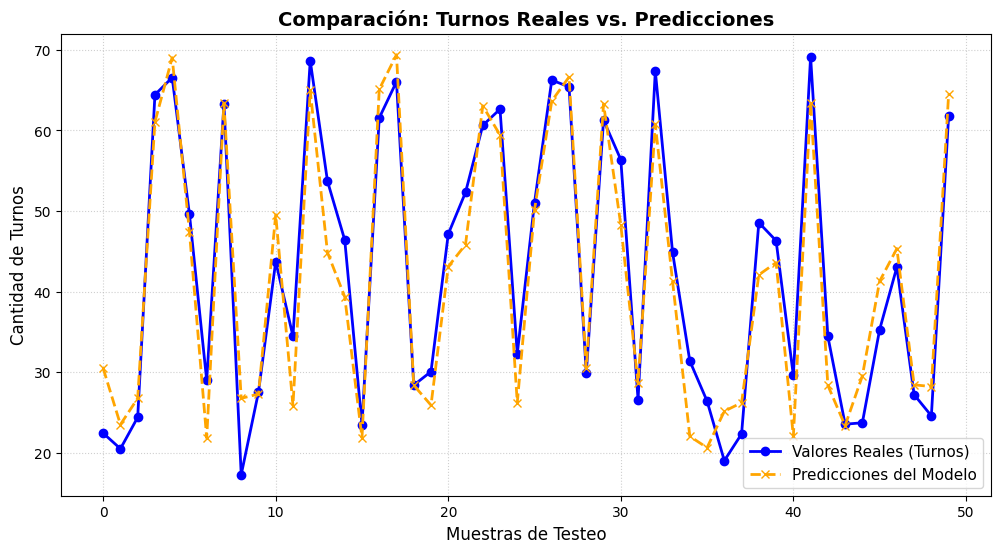

In [24]:
import matplotlib.pyplot as plt # Importa la librería para crear gráficos.

# Configuramos el tamaño del gráfico para que se vea prolijo.
plt.figure(figsize=(12, 6))

# Graficamos los valores reales y las predicciones (tomamos los primeros 50 para que se entienda bien).
plt.plot(y_test_plano[:50], label='Valores Reales (Turnos)', color='blue', marker='o', linewidth=2)
plt.plot(y_pred_final[:50], label='Predicciones del Modelo', color='orange', linestyle='--', marker='x', linewidth=2)

# Estética del gráfico para que quede bonito y fácil de leer.
plt.title('Comparación: Turnos Reales vs. Predicciones', fontsize=14, fontweight='bold') # Título del gráfico.
plt.xlabel('Muestras de Testeo', fontsize=12) # Etiqueta del eje X.
plt.ylabel('Cantidad de Turnos', fontsize=12) # Etiqueta del eje Y.
plt.legend(fontsize=11) # Muestra la leyenda de los colores.
plt.grid(True, linestyle=':', alpha=0.6) # Agrega una cuadrícula para mejor referencia.

# Mostramos el gráfico. ¡A ver qué tal!
plt.show()

## Resumen de Librerías de Machine Learning y Deep Learning utilizadas:

### Librerías de Propósito General (manejo de datos y operaciones numéricas):

*   **`pandas`**: Esencial para la manipulación y análisis de datos. Permite trabajar con DataFrames, estructuras de datos tabulares muy eficientes para organizar información.
*   **`numpy`**: Proporciona soporte para arrays y matrices, además de una gran colección de funciones matemáticas de alto nivel para operar con ellos. Fundamental para cualquier cálculo numérico en ML/DL.

### Librerías de Machine Learning (ML):

*   **`sklearn.model_selection.train_test_split`**: Una función clave de scikit-learn para dividir conjuntos de datos en subconjuntos de entrenamiento y prueba, asegurando que el modelo se evalúe en datos no vistos.
*   **`sklearn.linear_model.LogisticRegression`**: Implementa el algoritmo de Regresión Logística, utilizado principalmente para problemas de clasificación (ej. predecir si un cliente asiste o no a una cita).
*   **`sklearn.ensemble.RandomForestRegressor`**: Un algoritmo de *ensemble learning* que construye múltiples árboles de decisión y promedia sus predicciones para problemas de regresión (ej. predecir la duración de un servicio). Es robusto y suele ofrecer buen rendimiento.
*   **`sklearn.metrics.mean_absolute_error` (MAE)**: Una métrica de evaluación para modelos de regresión que mide la magnitud promedio de los errores en un conjunto de predicciones, sin considerar su dirección.
*   **`sklearn.metrics.r2_score` (R²)**: Otra métrica de evaluación para regresión que representa la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor más cercano a 1 indica un mejor ajuste del modelo.
*   **`joblib`**: Se utiliza para serializar y deserializar objetos Python de manera eficiente, lo cual es muy útil para guardar modelos de Machine Learning entrenados y cargarlos más tarde sin tener que re-entrenar.

### Librerías de Deep Learning (DL):

*   **`tensorflow`**: Una plataforma de código abierto de Google para Machine Learning. Permite construir y entrenar modelos de Deep Learning a gran escala.
*   **`tensorflow.keras` (o simplemente `keras`)**: Es una API de alto nivel para construir y entrenar modelos de Deep Learning de forma rápida y sencilla. Actúa como una interfaz más amigable para TensorFlow.
*   **`keras.layers.Dense`**: Una capa fundamental en las redes neuronales, que representa una capa completamente conectada (cada neurona de esta capa está conectada a cada neurona de la capa anterior).
*   **`keras.Sequential`**: Una forma sencilla de construir modelos de Keras, apilando capas una tras otra. Ideal para redes neuronales simples.
*   **`keras.callbacks.ModelCheckpoint`**: Un *callback* utilizado durante el entrenamiento de modelos de Keras para guardar el modelo automáticamente (o sus pesos) en intervalos regulares, especialmente el que tiene el mejor rendimiento en el conjunto de validación.
*   **`keras.callbacks.EarlyStopping`**: Otro *callback* que detiene el entrenamiento automáticamente si la métrica de monitoreo (ej. `val_loss`) deja de mejorar después de un cierto número de épocas (`patience`), previniendo el sobreajuste y ahorrando tiempo.
*   **`keras.callbacks.TensorBoard`**: Un *callback* que permite registrar métricas de entrenamiento y validación para ser visualizadas con la herramienta TensorBoard, lo que facilita el monitoreo y depuración del proceso de entrenamiento de la red neuronal.

### Librerías de Visualización:

*   **`matplotlib.pyplot`**: Una librería de Python para crear visualizaciones estáticas, animadas e interactivas. Se utiliza para graficar resultados, como la comparación entre valores reales y predichos por el modelo.